In [1]:
# CELL 0: Setup environment and import packages
# Need to append the project root directory to sys.path so we can import our custom
# config from the src directory without python complaining about ModuleNotFoundError.
import sys
from pathlib import Path
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the src folder is accessible
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import centralized paths
from src.config import DATASET_ROOT

In [2]:
# CELL 1: Scan the dataset directory and index all readable images
# We loop over class folders and load them using cv2.imread. If cv2 returns None,
# it means the image is unreadable/corrupt. We record the height, width, and path
# and load it into a pandas DataFrame because dataframes are super easy to query!
CLASS_MAPPING = {"class_0_genuine": "genuine", "class_1_forged": "forged"}
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

dataset_records = []
unreadable_files = []

print(f"Scanning Dataset at: {DATASET_ROOT}")

for folder_name, class_name in CLASS_MAPPING.items():
    folder_path = DATASET_ROOT / folder_name

    if not folder_path.exists():
        print(f"WARNING: Missing folder {folder_path}")
        continue

    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            # Check if image is readable
            img = cv2.imread(str(file_path))
            if img is None:
                unreadable_files.append(file_path)
                continue

            h, w = img.shape[:2]

            dataset_records.append(
                {
                    "file_path": str(file_path),
                    "file_name": file_path.name,
                    "class_name": class_name,
                    "width": w,
                    "height": h,
                    "extension": file_path.suffix.lower(),
                }
            )

df_dataset = pd.DataFrame(dataset_records)

print("=" * 40)
print(f"Total readable images: {len(df_dataset)}")
print(f"Unreadable images: {len(unreadable_files)}")
print("=" * 40)

Scanning Dataset at: E:\UOR\7thSem\Computer Vision\project-code\final_dataset
Total readable images: 525
Unreadable images: 0


Class Distribution:
class_name
genuine    324
forged     201
Name: count, dtype: int64


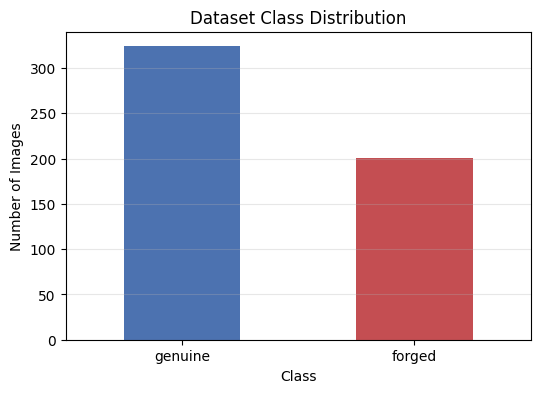

In [3]:
# CELL 2: Check dataset class balance and plot the distribution
# Let's count how many genuine vs forged stamps we have. If they are heavily
# imbalanced, the model training will be biased towards the majority class.
# Plotting a bar chart so we can include it in our final year report!
class_counts = df_dataset["class_name"].value_counts()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [4]:
# CELL 3: Check image formats and resolution distribution
# Checking extensions to make sure there are no weird file types in the dataset.
# Grouping by width and height to see what resolutions we are dealing with.
# Most scan documents are pretty high resolution!
print("Image File Extensions:")
print(df_dataset["extension"].value_counts())
print("\n" + "=" * 40 + "\n")

resolution_counts = (
    df_dataset.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Top Image Resolutions:")
print(resolution_counts.head())

Image File Extensions:
extension
.png    525
Name: count, dtype: int64


Top Image Resolutions:
    width  height  count
7    2481    3506    262
10   4962    7013    253
5    2481    3151      2
2    2481    3050      1
1    2356    3330      1


Genuine Stamps:


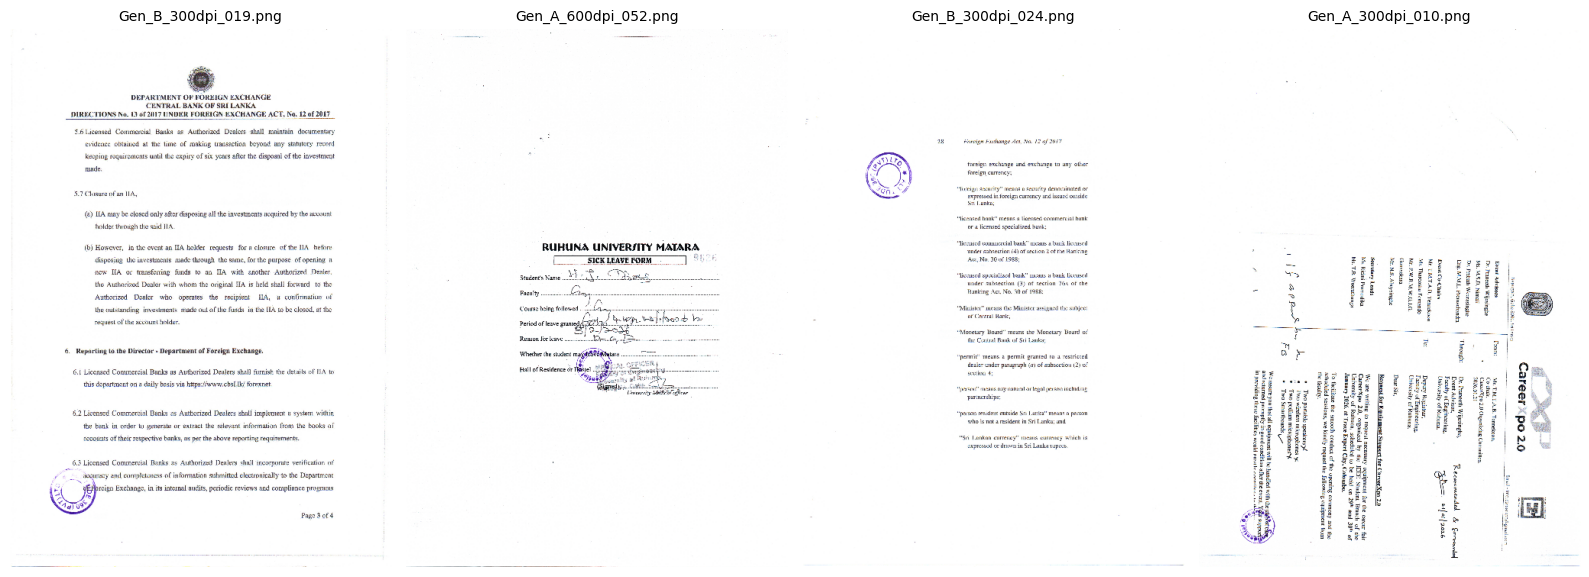

Forged Stamps:


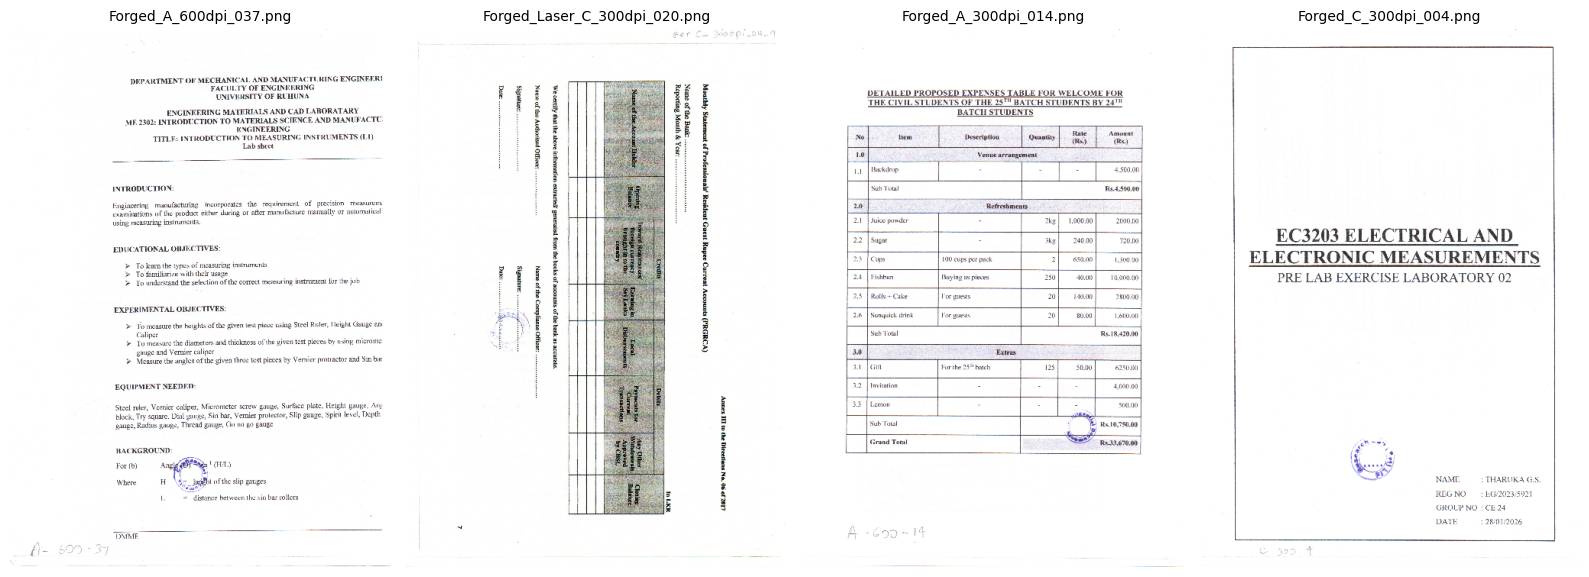

In [5]:
# CELL 4: Define a helper to plot random image samples side-by-side
# It's always a good idea to visually inspect the images. We resize them dynamically
# for the plot so matplotlib doesn't run out of memory or look too cluttered.
def show_samples(df, class_name, n=4, display_width=500):
    sample_df = df[df["class_name"] == class_name].sample(
        n=min(n, len(df)), random_state=42
    )

    plt.figure(figsize=(16, 6))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row["file_path"])
        h, w = img.shape[:2] # type: ignore
        scale = display_width / w
        img_small = cv2.resize(img, (display_width, int(h * scale))) # type: ignore

        plt.subplot(1, len(sample_df), i)
        plt.imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
        plt.title(row["file_name"], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Show Genuine Samples
print("Genuine Stamps:")
show_samples(df_dataset, "genuine")

# Show Forged Samples
print("Forged Stamps:")
show_samples(df_dataset, "forged")